# 4. Equilibrium criticality: the central charge from DMRG

We check that the ANNNI-type model is actually
critical and identify its universality class in equilibrium. We do this with DMRG: compute the
ground state, read off the central charge $c$ from the scaling of the ground-state entanglement
entropy, and track $c(p)$ as the NNN coupling is turned on.

## CFT prediction for the ground-state entanglement

For a critical 1D system, CFT predicts that the von Neumann entropy of a block of length $l$ in an
open chain of length $L$ scales logarithmically,

$$ S_{\rm vN}(l,L) = \frac{c}{6}\,\log\!\left[\frac{L}{\pi}\sin\frac{l\pi}{L}\right] + k, $$

with $c$ the central charge, and $k$ non-universal. (Note: the coefficient is $c/6$ for open boundary
conditions, vs $c/3$ for periodic) 

Plotting $S_{\rm vN}$ against the scaling variable
$\tfrac16\log[(L/\pi)\sin(l\pi/L)]$ therefore gives a straight line of slope exactly $c$. We fit the
central half of the chain (avoiding boundary effects) over a sweep of $p$.

Alcaraz argued, by finite-size scaling, that for $p\lesssim 1.5$ the model stays critical and in the
Ising class, so $c$ should remain close to $1/2$.

In [1]:
include("../src/thesislib.jl")
using LsqFit, Printf

# von Neumann entropy across every bond of an MPS
function compute_vn_entropy(psi::MPS)
    N = length(psi)
    S = Float64[]
    for b in 1:(N-1)
        orthogonalize!(psi, b)
        inds_b = b == 1 ? (siteind(psi,b),) : (linkind(psi,b-1), siteind(psi,b))
        _, Sv, _ = svd(psi[b], inds_b)  # inds_b = left tensor indices
        s = 0.0
        for n in 1:dim(Sv,1)
            pr = Sv[n,n]^2
            if pr > 1e-12
                s -= pr * log(pr)
            end
        end
        push!(S, s)
    end
    return S
end

alcaraz_H(sites, lambda, p) = MPO(alcaraz_opsum(length(sites), lambda, p), sites)

alcaraz_H (generic function with 1 method)

## $c(p)$ across the phase diagram

We run DMRG for $p\in[0,2]$ on a long chain ($N=300$), extract the mid-chain
slope, and plot $c(p)$.

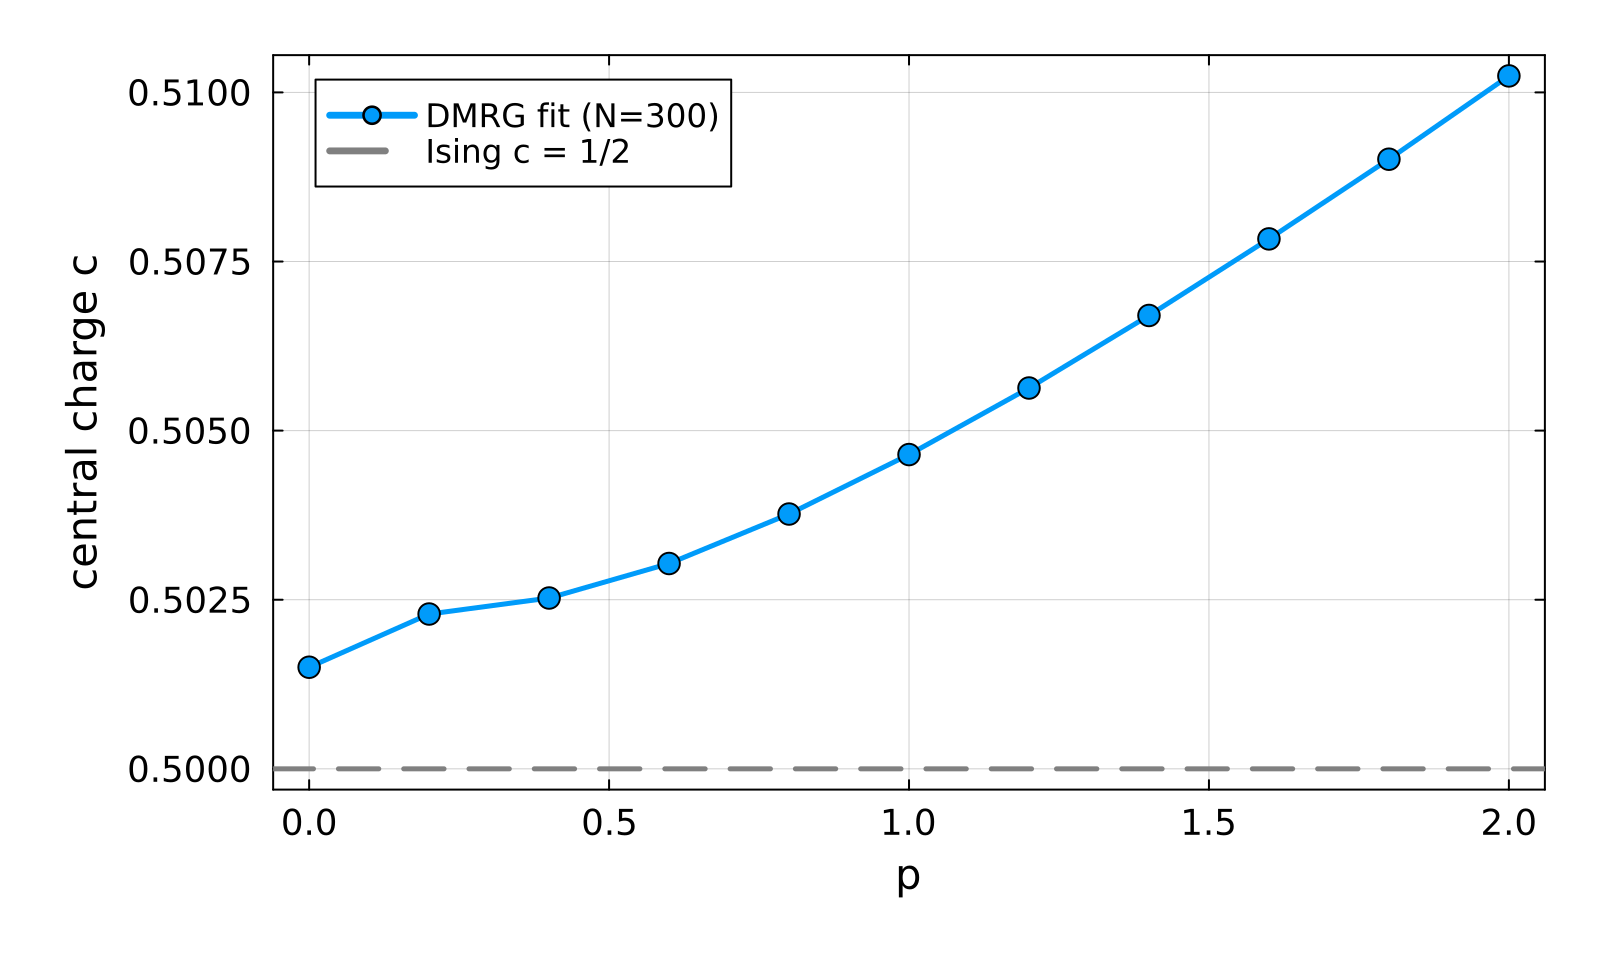

In [2]:
thesis_plot_theme!()   # thesis-quality styling
using JLD2

N = 300
lambda = 1.0

nsweeps = 15
maxdims = [10, 20, 100, 200, 400]
cutoffs = [1e-10]
noises = [1e-4, 1e-5, 1e-6, 0.0]

p_values = 0.0:0.2:2.0
@. linmodel(x, q) = q[1]*x + q[2]

# Cache the c(p) sweep so the figure is regenerable without re-running the N=300 DMRG at every p.
cvsp_cache = "../results/data/nb4_cvsp.jld2"
if isfile(cvsp_cache)
    actual_p, estimated_c = load(cvsp_cache, "p", "c")
else
    sites = siteinds("S=1/2", N)
    actual_p = Float64[]
    estimated_c = Float64[]
    @showprogress "DMRG sweep over p" for p in p_values
        H   = alcaraz_H(sites, lambda, p)
        _, psi = dmrg(H, randomMPS(sites, 10); nsweeps=nsweeps, maxdim=maxdims,
                      cutoff=cutoffs, noise=noises, outputlevel=0)
        S   = compute_vn_entropy(psi)

        quarter = div(N, 4)
        lo = iseven(quarter) ? quarter : quarter + 1

        hi = div(3N, 4)
        lfit = lo:2:hi

        xv  = [log((N/pi)*sin(l*pi/N))/6 for l in lfit]

        fit = curve_fit(linmodel, xv, S[lfit], [1.0, 1.0])

        push!(actual_p, p)
        push!(estimated_c, fit.param[1])
        @printf("  p=%.1f  c=%.3f\n", p, fit.param[1])
    end
    mkpath("../results/data")
    jldsave(cvsp_cache; p=actual_p, c=estimated_c)
end

# No in-figure title (thesis convention): the caption carries the description.
figP = plot(actual_p, estimated_c; xlabel="p", ylabel="central charge c", marker=:circle,
     label="DMRG fit (N=$N)")
hline!(figP, [0.5]; ls=:dash, color=:gray, label="Ising c = 1/2")

mkpath("../results/imgs")
savefig(figP, "../results/imgs/p_dependence.png"); figP

## Finite-size scaling of the mid-chain entropy

A second, independent read of $c$ comes from the $L$-dependence at the central cut. Setting
$l=L/2$ in the scaling law (where $\sin(\pi/2)=1$) collapses it to

$$ S_{\rm vN}(L/2) = \frac{c}{6}\,\log L + k', $$

so the mid-chain entropy plotted against $\log L$ is a straight line of slope $c/6$. We run DMRG over
a ladder of system sizes for two values of $p$ and read $c$ from the slope.

Because the temporal analysis in the rest of the thesis uses the Rényi-2 entropy rather than the von Neumann one, we read $c$ here from *both*, computed from the same mid-bond Schmidt spectrum. The Rényi-2 entropy $S_2(L/2)=-\log\sum_n p_n^2$ has open-chain mid-bond slope $c/8$ (the $n=2$ member of the family $\tfrac{c}{12}(1+\tfrac1n)$). Both are plotted below; the fits give $c(\mathrm{vN})\approx0.51$ and $c(\text{Rényi-2})\approx0.58$.

The Rényi-2 read sits a little high. This is not an error: Rényi-$n$ entropies with $n>1$ carry stronger, oscillating corrections to scaling than the von Neumann entropy, so a naive linear fit of the mid-bond value is biased upward. It is the *equilibrium counterpart* of the finite-time bias that inflates the temporal Rényi-2 read (there $0.5\to0.67$; here $0.5\to0.58$) — the same effect seen along a different axis. This is exactly why we keep the von Neumann entropy as the primary equilibrium estimator (it is clean and free, since DMRG hands us the full Schmidt spectrum), while the temporal problem uses Rényi-2 out of necessity and handles its bias through the finite-time correction and calibration.

p=0.10 : c(von Neumann) = 0.511,   c(Rényi-2 cross-check) = 0.584
p=0.50 : c(von Neumann) = 0.514,   c(Rényi-2 cross-check) = 0.588


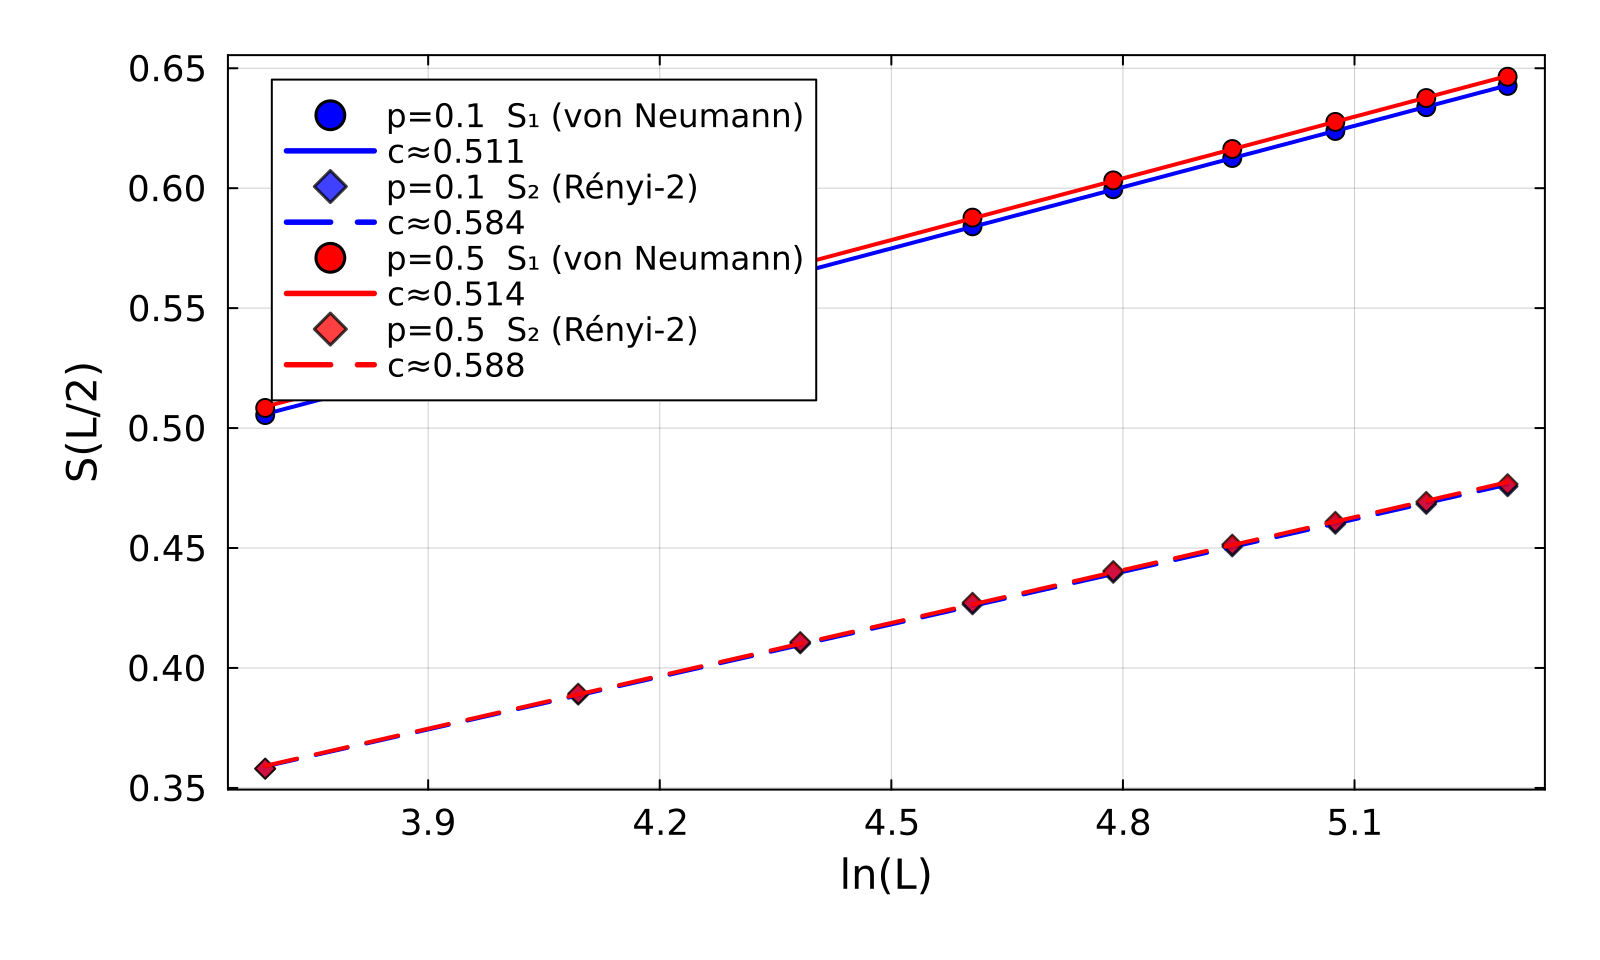

In [3]:
thesis_plot_theme!()   # thesis-quality styling
using JLD2

N_values = [40, 60, 80, 100, 120, 140, 160, 180, 200]
lambda = 1.0

@. linmodel(x, q) = q[1]*x + q[2]

# Finite-size scaling of the mid-chain entropy. From the SAME mid-bond Schmidt spectrum we
# compute two entropies: the von Neumann entropy S1 = -Σ p·log p (our primary equilibrium
# estimator, mid-bond open-chain slope c/6) and the Rényi-2 entropy S2 = -log Σ p² (slope
# c/8). The temporal analysis later in the thesis uses the Rényi-2 entropy, so this is a
# consistency cross-check: in equilibrium, where the full Schmidt spectrum is available for
# free, the Rényi-2 entropy must recover the same central charge as the von Neumann one.
fss_cache = "../results/data/nb4_fss.jld2"
if isfile(fss_cache)
    fss_data = load(fss_cache, "data")
else
    fss_data = Dict{Float64,Any}()
    for p in [0.1, 0.5]
        S1 = Float64[]     # von Neumann
        S2 = Float64[]     # Rényi-2
        @showprogress "finite-size scaling p=$p" for N in N_values
            sites  = siteinds("S=1/2", N)
            _, psi = dmrg(alcaraz_H(sites, lambda, p), randomMPS(sites, 10);
                          nsweeps=15, maxdim=[10,20,100,200,400], cutoff=[1e-10],
                          noise=[1e-4,1e-5,1e-6,0.0], outputlevel=0)
            mid = div(N,2)
            orthogonalize!(psi, mid)
            _, Sv, _ = svd(psi[mid], (linkind(psi,mid-1), siteind(psi,mid)))

            # Schmidt probabilities p_n = (singular value)^2 at the mid bond.
            probs = [Sv[n,n]^2 for n in 1:dim(Sv,1) if Sv[n,n]^2 > 1e-12]
            s1 = -sum(pr * log(pr) for pr in probs)      # von Neumann
            s2 = -log(sum(pr^2 for pr in probs))         # Rényi-2
            push!(S1, s1)
            push!(S2, s2)
        end
        fss_data[p] = (vn = S1, r2 = S2)
    end
    mkpath("../results/data")
    jldsave(fss_cache; data=fss_data)
end

# No in-figure title (thesis convention): the caption carries the description.
figL = plot(xlabel="ln(L)", ylabel="S(L/2)", legend=:topleft)

for (p, col) in zip([0.1, 0.5], [:blue, :red])
    x = log.(N_values)

    # Primary read: von Neumann entropy, mid-bond slope = c/6.
    S1 = fss_data[p].vn
    f1 = curve_fit(linmodel, x, S1, [0.1, 1.0])
    c1 = 6 * f1.param[1]

    # Cross-check: Rényi-2 entropy, mid-bond slope = c/8.
    S2 = fss_data[p].r2
    f2 = curve_fit(linmodel, x, S2, [0.1, 1.0])
    c2 = 8 * f2.param[1]

    @printf("p=%.2f : c(von Neumann) = %.3f,   c(Rényi-2 cross-check) = %.3f\n", p, c1, c2)

    scatter!(figL, x, S1; label="p=$p  S₁ (von Neumann)", color=col, ms=5)
    plot!(figL, x, linmodel(x, f1.param); label="c≈$(round(c1,digits=3))", color=col, lw=2)
    scatter!(figL, x, S2; label="p=$p  S₂ (Rényi-2)", color=col, ms=5, marker=:diamond, alpha=0.75)
    plot!(figL, x, linmodel(x, f2.param); label="c≈$(round(c2,digits=3))", color=col, lw=2, ls=:dash)
end

mkpath("../results/imgs")
savefig(figL, "../results/imgs/cft_L.png")
figL

## The full entanglement profile and the chord fit

The $c(p)$ sweep above fits only the mid-chain slope. It is worth seeing the whole spatial
entanglement profile for a single ground state and checking that it follows the conformal
chord law across the entire chain (open boundary conditions):

$$ S_{\rm vN}(x) = \frac{c}{6}\,\log\!\left[\frac{2L}{\pi}\sin\frac{\pi x}{L}\right] + g. $$

We run DMRG once per $p$ at fixed $N=100$, sweep every cut, and fit the bulk quarter -- three-quarters
(where boundary effects are negligible).

p=0.00 : c = 0.5080
p=0.10 : c = 0.5072


p=0.20 : c = 0.5070
p=0.30 : c = 0.5071
p=0.40 : c = 0.5075
p=0.50 : c = 0.5081


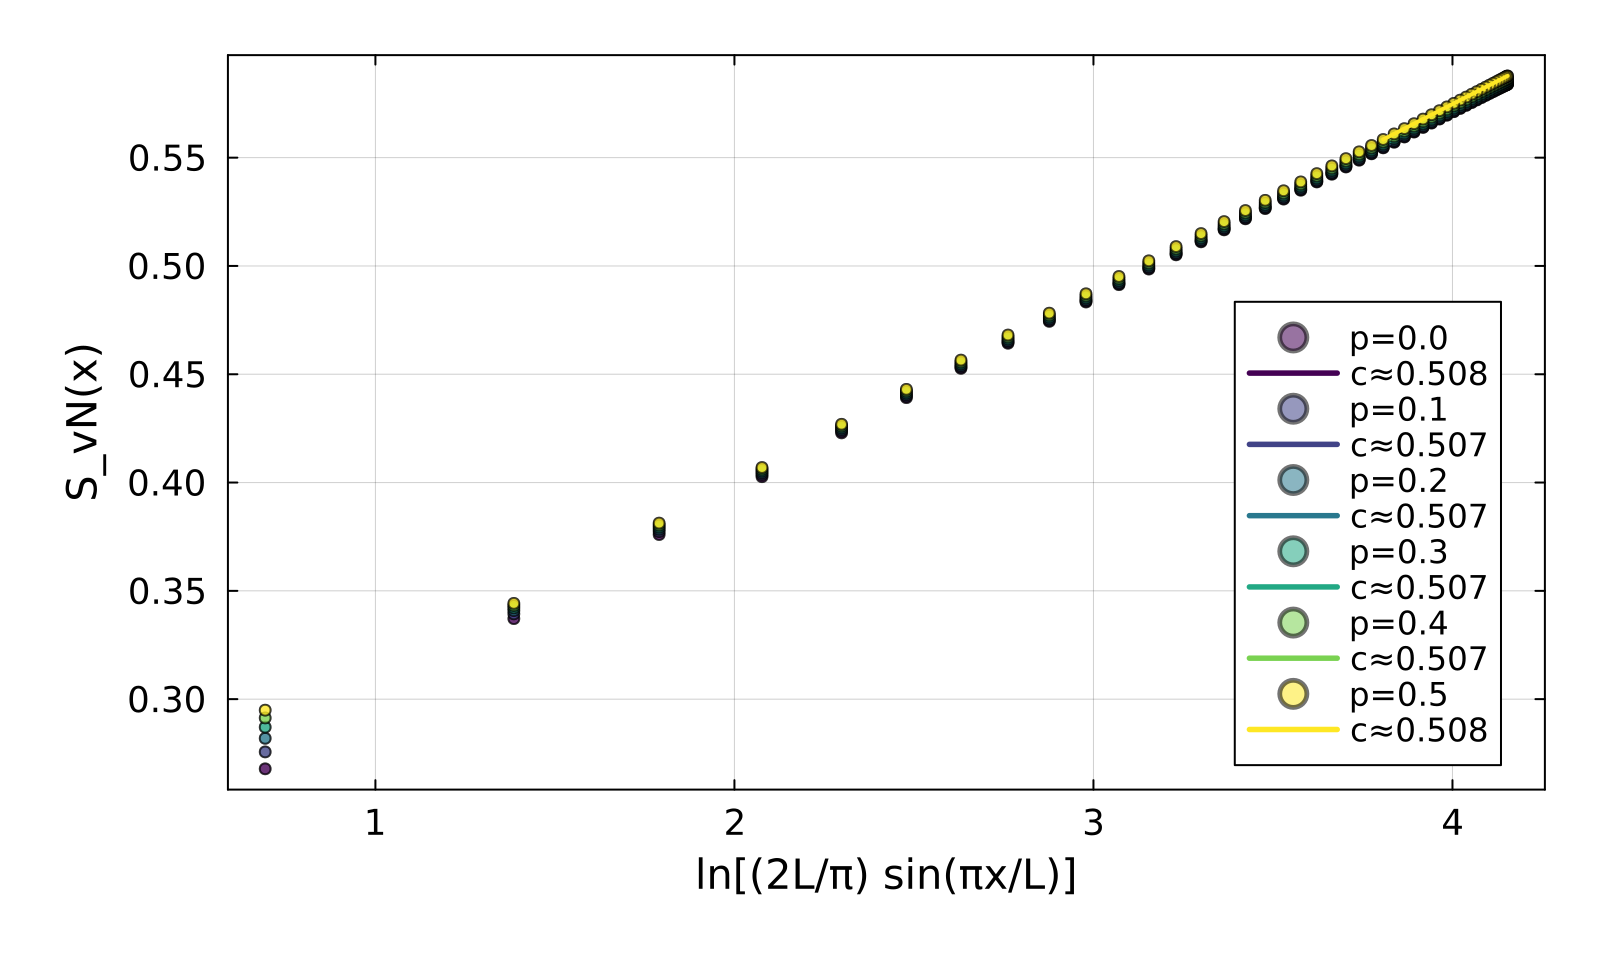

In [4]:
thesis_plot_theme!()   # thesis-quality styling
using JLD2

N = 100
lambda = 1.0
bonds = collect(1:N-1)
p_chord = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]   # the range this work uses, in steps of 0.1

@. chordmodel(x, q) = (q[1]/6)*x + q[2]              # q[1] = c, q[2] = g

# Per-cut entanglement profiles at fixed N (heavy N=100 DMRG, maxdim up to 1000). The cache is
# filled per p, so adding a new coupling only runs the ones that are missing.
chord_cache = "../results/data/nb4_chord.jld2"
chord_data = isfile(chord_cache) ? load(chord_cache, "data") : Dict{Float64,Vector{Float64}}()

missing_p = [p for p in p_chord if !haskey(chord_data, p)]
if !isempty(missing_p)
    for p in missing_p
        @printf("running DMRG for the chord profile at p=%.1f ...\n", p)
        sites  = siteinds("S=1/2", N)
        _, psi = dmrg(alcaraz_H(sites, lambda, p), randomMPS(sites, 10);
                      nsweeps=50, maxdim=[20,100,200,400,800,1000], cutoff=[1e-12],
                      noise=[1e-4,1e-5,1e-6,0.0], outputlevel=0)
        chord_data[p] = compute_vn_entropy(psi)
    end
    mkpath("../results/data")
    jldsave(chord_cache; data=chord_data)
end

figX = plot(xlabel="ln[(2L/π) sin(πx/L)]", ylabel="S_vN(x)", legend=:bottomright,
            framestyle=:box)
palette_chord = cgrad(:viridis, length(p_chord), categorical=true)

for (i, p) in enumerate(p_chord)
    S    = chord_data[p]
    xv   = log.((2N/pi) .* sin.(pi .* bonds ./ N))
    bulk = findall(b -> N/4 <= b <= 3N/4, bonds)     # fit the bulk, skip the boundaries

    fit = curve_fit(chordmodel, xv[bulk], S[bulk], [0.5, 1.0])
    c   = fit.param[1]

    @printf("p=%.2f : c = %.4f\n", p, c)
    scatter!(figX, xv, S; label="p=$p", color=palette_chord[i], ms=3, alpha=0.55)
    plot!(figX, xv[bulk], chordmodel(xv[bulk], fit.param);
          label="c≈$(round(c,digits=3))", color=palette_chord[i], lw=2)
end

mkpath("../results/imgs")
savefig(figX, "../results/imgs/cft_chord_equilibrium.png")
figX

## Results

We have performed three independent fits, which all agree. The mid-chain slope of $c(p)$ gives $c(p{=}0)\approx0.502$ (the small
excess over $1/2$ is a well-understood finite-size artifact), and it drifts only gently upward as
$p$ grows, staying close to $1/2$ even at $p=2$. The finite-size scaling $S(L/2)$ vs $\log L$ and the
full chord fit $S(x)$ both return $c\approx1/2$ at $p=0$ and $p=0.1$ as well. 

Strong numerical support for Alcaraz's claim: the NNN coupling does not drive the system into a
new phase. It remains critical and in the Ising universality class, so the CFT framework is a
legitimate tool for its dynamics.

## The sound velocity $v(p)$ from the equilibrium dispersion

The central charge above is one universal number from the equilibrium critical point. The sound velocity $v(p)$, on the other hand, is a non-universal constant, and the temporal-entropy method of NB6-7 needs it to convert transfer-matrix phases into scaling dimensions. We measure it here.

## Alcaraz's own formula

Alcaraz (2016) gives a direct formula for the sound velocity of our model:
$$ v_s(L) = \frac{L}{2\pi}\Big[E_1\big(\tfrac{2\pi}{L}\big) - E_1(0)\Big], $$
where $E_1(P)$ is the lowest energy at momentum $P$ within the $Z(2)$ magnetic sector.

**Where this comes from.** Put the model on a ring (periodic boundary conditions) of $L$ sites and diagonalize it exactly. It is a static, equilibrium calculation (the same equilibrium finite-size setup as the DMRG sweep above, no transverse method). Near the critical point, energy levels organize by CFT scaling dimension: an operator of dimension $x$ sits at $E=(2\pi v/L)\,x$ above the ground state. The lowest operator in the magnetic sector is the order parameter $\sigma$ (dimension $x=1/8$), and its first momentum-carrying partner sits exactly one rung higher, at $E+2\pi v/L$. The gap between them is therefore exactly $2\pi v/L$ (the formula above).

**The magnetic sector.** $H_{\text{Alcaraz}}$ is left unchanged by flipping every spin in the ordering direction at once, $P=\prod_i\sigma^x_i$ (each $ZZ$ bond picks up two sign flips under this flip; the field terms are already built from $\sigma^x$). Since $[H,P]=0$, every state carries a definite parity $\pm1$: the ground state sits in $P=+1$, while $\sigma$ sits in $P=-1$ (Alcaraz's "magnetic" sector). Restricting to $P=-1$ removes any ambiguity about which excitation the gap is measuring.

In [5]:
using SparseArrays, LinearAlgebra

# A basis state is an integer 1..2^N. `bits_of` turns it into a length-N vector of 0/1 (bit k = 1
# means "spin down" at site k, in the σᶻ ordering direction). `index_of` is the inverse map.
function bits_of(state_index, N)
    return digits(state_index - 1, base=2, pad=N)
end

function index_of(bits)
    return 1 + sum(bits[site] * 2^(site - 1) for site in eachindex(bits))
end

# H (Alcaraz) on a PERIODIC ring (site N+1 ≡ site 1), built here directly from bit manipulation (not via ITensors),
# so the construction is transparent and easy to check on its own terms.
function alcaraz_ring_hamiltonian(N, lambda, p)
    dimension = 2^N
    rows = Int[]
    cols = Int[]
    vals = Float64[]

    for state_index in 1:dimension
        bits = bits_of(state_index, N)
        spin_at(site) = 1 - 2 * bits[site]   # bit 0 -> spin +1 (up), bit 1 -> spin -1 (down)

        diagonal_energy = 0.0
        for site in 1:N
            neighbour = mod1(site + 1, N)
            diagonal_energy -= spin_at(site) * spin_at(neighbour)
        end
        for site in 1:N
            next_nearest_neighbour = mod1(site + 2, N)
            diagonal_energy -= p * spin_at(site) * spin_at(next_nearest_neighbour)
        end
        push!(rows, state_index)
        push!(cols, state_index)
        push!(vals, diagonal_energy)

        for site in 1:N
            flipped_bits = copy(bits)
            flipped_bits[site] = 1 - flipped_bits[site]
            push!(rows, index_of(flipped_bits))
            push!(cols, state_index)
            push!(vals, -lambda)
        end
        for site in 1:N
            neighbour = mod1(site + 1, N)
            flipped_bits = copy(bits)
            flipped_bits[site] = 1 - flipped_bits[site]
            flipped_bits[neighbour] = 1 - flipped_bits[neighbour]
            push!(rows, index_of(flipped_bits))
            push!(cols, state_index)
            push!(vals, -p * lambda)
        end
    end

    return sparse(rows, cols, vals, dimension, dimension)
end

# Translation by one site, needed to read off momentum: site k of the shifted state carries
# whatever site k-1 carried before the shift.
function cyclic_shift_operator(N)
    dimension = 2^N
    rows = Int[]
    cols = Int[]
    vals = Float64[]
    for state_index in 1:dimension
        bits = bits_of(state_index, N)
        shifted_bits = [bits[mod1(site - 1, N)] for site in 1:N]
        push!(rows, index_of(shifted_bits))
        push!(cols, state_index)
        push!(vals, 1.0)
    end
    return sparse(rows, cols, vals, dimension, dimension)
end

# The Z(2) symmetry P = Π_i σˣ_i: flips every spin at once. On our bit basis this is simply
# "flip every bit simultaneously".
function global_flip_operator(N)
    dimension = 2^N
    rows = Int[]
    cols = Int[]
    vals = Float64[]
    for state_index in 1:dimension
        bits = bits_of(state_index, N)
        flipped_bits = 1 .- bits
        push!(rows, index_of(flipped_bits))
        push!(cols, state_index)
        push!(vals, 1.0)
    end
    return sparse(rows, cols, vals, dimension, dimension)
end

# H commutes with both T (translation) and P (the spin flip), so every
# energy level of H automatically has a well-defined momentum AND a well-defined parity. The catch
# is DEGENERACY: when two or more states share the exact same energy, the diagonalization routine
# hands them back as some arbitrary mixture of each other -- the individually clean momentum/parity
# labels still exist, but they're hidden inside that mixture. We need to "untangle" each degenerate
# group back into the basis where both labels are clean again.
#
# THE TRICK: rather than diagonalizing T and P separately (which risks re-mixing states that are
# ALSO degenerate under each operator on its own), we diagonalize one GENERIC linear combination of
# them, e.g. c1*T + c2*P with essentially arbitrary weights. Since T and P commute, they share a
# common eigenbasis -- diagonalizing this mixture lands exactly on that shared basis, handing back
# eigenvectors that are simultaneously clean eigenstates of BOTH T and P. Standard linear-algebra
# shortcut, nothing physics-specific about it.
#
# WHAT THE CODE DOES: group H's eigenvalues into degenerate clusters (energies equal within
# `degeneracy_tol`); for any cluster bigger than one state, build and diagonalize that generic
# combination; then read off ⟨state|T|state⟩ and ⟨state|P|state⟩ for every state -- these
# expectation values are what get turned into momentum and parity labels afterwards.

function simultaneous_expectation_values(sorted_energies, eigenvectors_matrix, operators, N; degeneracy_tol=1e-8)
    n_states = length(sorted_energies) 
    n_operators = length(operators)         # here it is 2: T and P
    expectation_values = zeros(ComplexF64, n_states, n_operators)   # one row per state, one column per operator

    # `sorted_energies` comes out of `eigen` already sorted from lowest to highest, so degenerate
    # states (equal energy) always sit next to each other in the list. This loop walks along that
    # sorted list and finds each contiguous run of equal energies (one degenerate
    # cluster = a group of eigenstates of H that all share the same energy). A cluster of size 1 is
    # just an ordinary, non-degenerate state.
    cluster_start = 1
    while cluster_start <= n_states
        cluster_end = cluster_start
        while cluster_end < n_states && abs(sorted_energies[cluster_end+1] - sorted_energies[cluster_start]) < degeneracy_tol
            cluster_end += 1   # extend the run while the next energy is still "the same" within tolerance
        end

        cluster_vectors = eigenvectors_matrix[:, cluster_start:cluster_end]   # the eigenvectors in this one cluster
        cluster_size = cluster_end - cluster_start + 1

        if cluster_size == 1
            # A non-degenerate state is automatically a clean eigenstate of T and P too, nothing to untangle, use it as is.
            joint_basis = cluster_vectors
        else
            # A degenerate cluster needs untangling. First, restrict each operator to just this
            # cluster's subspace: `cluster_vectors' * (operators[j] * cluster_vectors)` is a small
            # matrix (cluster_size x cluster_size) representing operator j acting ONLY within this
            # degenerate subspace, written in the basis of the cluster's own eigenvectors.
            generic_coefficients = [1.0 + 0.37im * j for j in 1:n_operators]   # arbitrary, fixed weights -- any generic choice works
            combined_operator = sum(generic_coefficients[j] * (cluster_vectors' * (operators[j] * cluster_vectors)) for j in 1:n_operators)

            # Diagonalizing this one mixed operator finds the basis where T and P are BOTH clean at
            # once. `combination_eigenvectors` holds the recipe (as columns of coefficients) 
            # for combining the original cluster eigenvectors into the untangled ones.
            _, combination_eigenvectors = eigen(combined_operator)

            # Turn those coefficients back into actual full-length state vectors.
            joint_basis = cluster_vectors * combination_eigenvectors
        end

        # `joint_basis` holds clean simultaneous eigenstates, just read off each operator's expectation value
        # ⟨state|operator|state⟩ for every state in this cluster.
        for (local_index, global_index) in enumerate(cluster_start:cluster_end)
            state = joint_basis[:, local_index]
            for j in 1:n_operators
                expectation_values[global_index, j] = state' * (operators[j] * state)
            end
        end

        cluster_start = cluster_end + 1   # move on to the next cluster
    end

    return expectation_values
end

# Alcaraz's Eq. (19), directly: build H, the translation operator T, and the parity operator P;
# diagonalize the low-lying spectrum; find E1(0) and E1(2π/N), both restricted to the magnetic
# (P=-1) sector; return the velocity.
function alcaraz_sound_velocity(N, lambda, p; n_low_states=10)
    hamiltonian = alcaraz_ring_hamiltonian(N, lambda, p)
    shift_operator = cyclic_shift_operator(N)
    parity_operator = global_flip_operator(N)

    spectrum = eigen(Symmetric(Matrix(hamiltonian)))
    ground_state_energy = spectrum.values[1]
    excitation_energies = spectrum.values[2:n_low_states] .- ground_state_energy
    excited_eigenvectors = spectrum.vectors[:, 2:n_low_states]

    joint_values = simultaneous_expectation_values(excitation_energies, excited_eigenvectors,
                                                     [shift_operator, parity_operator], N)
    momenta = round.(Int, angle.(joint_values[:, 1]) .* N ./ (2 * pi))
    parities = round.(Int, real.(joint_values[:, 2]))

    magnetic_zero_momentum = findall((momenta .== 0) .& (parities .== -1))
    magnetic_nonzero_momentum = findall((momenta .!= 0) .& (parities .== -1))
    if isempty(magnetic_zero_momentum) || isempty(magnetic_nonzero_momentum)
        error("magnetic-sector states not found within the $n_low_states lowest levels -- widen the window")
    end

    e1_zero = minimum(excitation_energies[magnetic_zero_momentum])
    smallest_nonzero_index = magnetic_nonzero_momentum[argmin(abs.(momenta[magnetic_nonzero_momentum]))]
    e1_nonzero = excitation_energies[smallest_nonzero_index]
    momentum_used = momenta[smallest_nonzero_index]

    return N * (e1_nonzero - e1_zero) / (2 * pi * abs(momentum_used))
end

# Validate on p=0, where the exact answer is known: v=2.
println("Validation at p=0 (exact critical TFIM, must recover v=2):\n")
for N in [10, 12]
    v = alcaraz_sound_velocity(N, 1.0, 0.0)
    @printf("  N=%-3d  v = %.4f\n", N, v)
end

Validation at p=0 (exact critical TFIM, must recover v=2):

  N=10   v = 1.9673
  N=12   v = 1.9772


Both sizes recover $v\approx2$ cleanly, and tighten toward it as $N$ grows, showing that the formula and construction are correct.

## The velocity grows with frustration

With the method validated, we run it at the frustrated points, $p=0.1,0.3,0.5$.


v(p) at two ring sizes:



  p      v (N=10)    v (N=12)  
  0.0    1.9673      1.9772    


  0.1    2.5707      2.6007    
  0.2    3.1565      3.2073    
  0.3    3.7247      3.7972    
  0.4    4.2756      4.3707    
  0.5    4.8096      4.9284    

saved v(p) [N=12] to results/data/alcaraz_velocity.jld2:  v(0.0)=1.977  v(0.1)=2.601  v(0.2)=3.207  v(0.3)=3.797  v(0.4)=4.371  v(0.5)=4.928


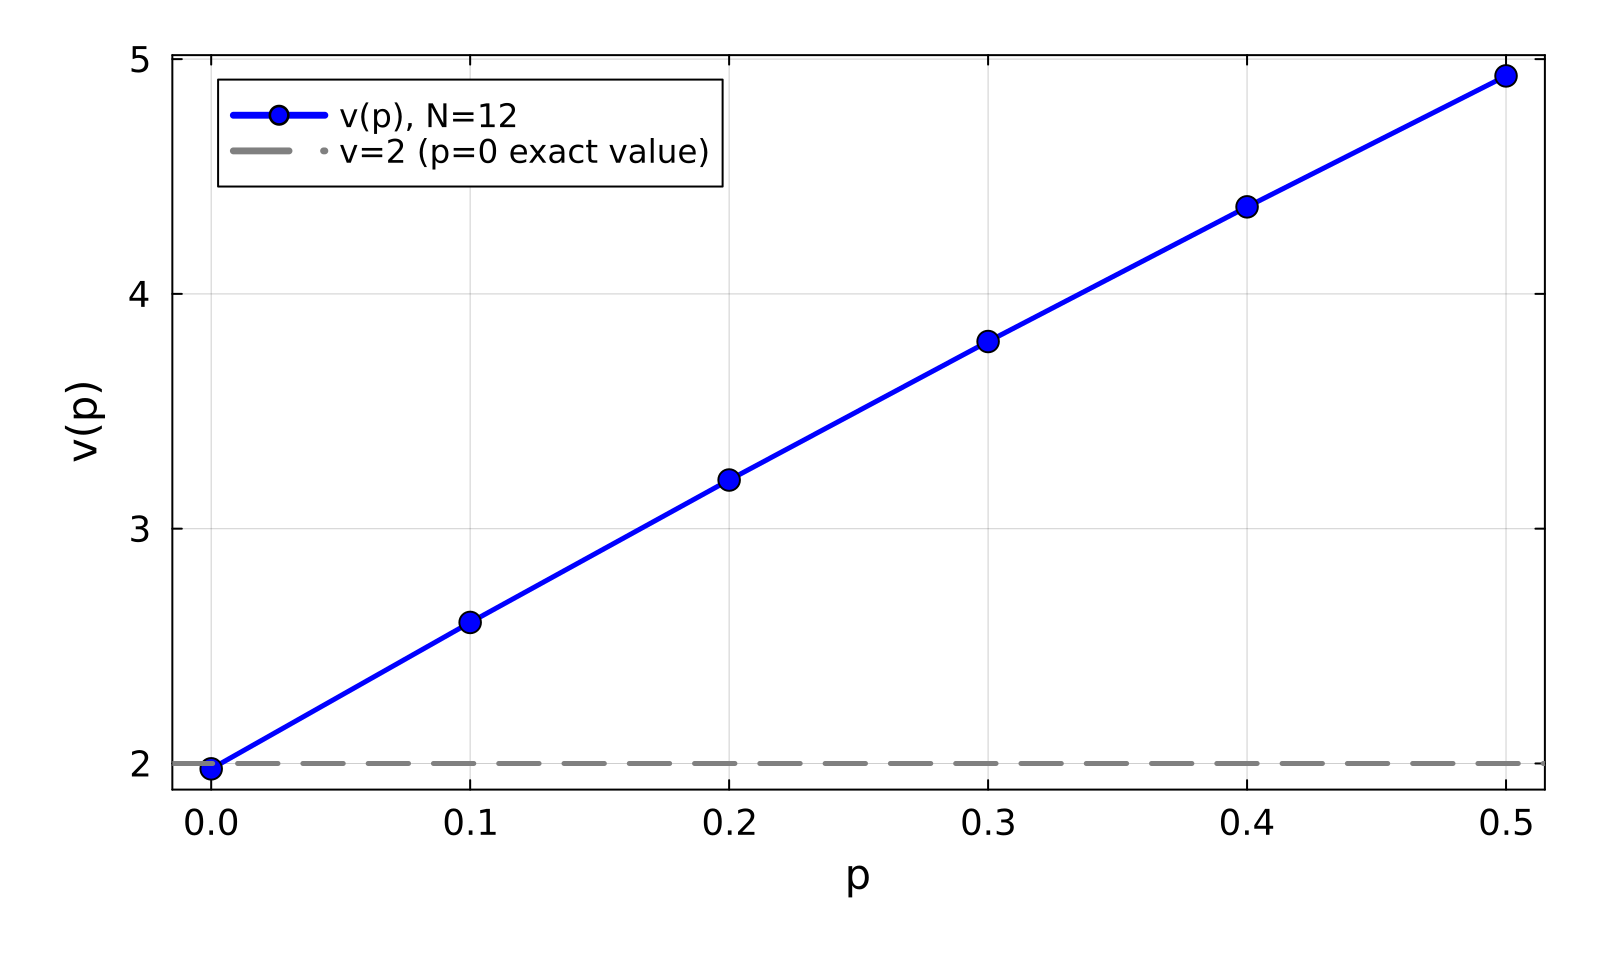

In [6]:
# Sound velocity on the same p grid as the chord fit above. Exact diagonalisation of the periodic
# ring at two sizes, so we can see the value settle as N grows. Cached per (p, N): re-running only
# computes couplings that are not already stored.
using JLD2

p_sweep_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
N_sweep_values = [10, 12]

velocity_table_cache = "../results/data/nb4_velocity_table.jld2"
v_sweep_results = isfile(velocity_table_cache) ?
    load(velocity_table_cache, "v") : Dict{Tuple{Float64,Int},Float64}()

missing_keys = Tuple{Float64,Int}[]
for p in p_sweep_values
    for N in N_sweep_values
        haskey(v_sweep_results, (p, N)) || push!(missing_keys, (p, N))
    end
end

if !isempty(missing_keys)
    for (p, N) in missing_keys
        @printf("diagonalising the ring at p=%.1f, N=%d ...\n", p, N)
        v_sweep_results[(p, N)] = alcaraz_sound_velocity(N, 1.0, p)
    end
    mkpath("../results/data")
    jldsave(velocity_table_cache; v=v_sweep_results)
end

println("\nv(p) at two ring sizes:\n")
@printf("  %-5s  %-10s  %-10s\n", "p", "v (N=10)", "v (N=12)")
for p in p_sweep_values
    @printf("  %-5.1f  %-10.4f  %-10.4f\n", p, v_sweep_results[(p, 10)], v_sweep_results[(p, 12)])
end

thesis_plot_theme!()   # thesis-quality styling
velocity_plot = plot(
    xlabel="p", ylabel="v(p)", framestyle=:box, grid=true, legend=:topleft,
)
plot!(velocity_plot, p_sweep_values, [v_sweep_results[(p, 12)] for p in p_sweep_values];
      marker=:circle, lw=2.5, color=:blue, label="v(p), N=12")
hline!(velocity_plot, [2.0]; ls=:dash, color=:gray, label="v=2 (p=0 exact value)")

mkpath("../results/imgs")
savefig(velocity_plot, "../results/imgs/nb4_velocity_vs_p.png")

# The N=12 row is what the downstream notebooks read (NB7's temporal-CFT analysis), so it also goes
# to its own small cache under the name they expect.
velocity_vs_p = Dict(p => v_sweep_results[(p, 12)] for p in p_sweep_values)
jldsave("../results/data/alcaraz_velocity.jld2"; v=velocity_vs_p)
@printf("\nsaved v(p) [N=12] to results/data/alcaraz_velocity.jld2:  %s\n",
        join([@sprintf("v(%.1f)=%.3f", p, velocity_vs_p[p]) for p in p_sweep_values], "  "))

velocity_plot

The velocity increases steeply, and the two ring sizes agree closely. 

We now compare the full spectrum against this thesis's own trusted `alcaraz_opsum` builder (the one validated by TDVP elsewhere) to see if it matches exactly the ring Hamiltonian's NNN and XX terms.

In [7]:
# We Strip the periodic wrap-around (matching alcaraz_opsum's open-chain convention) and
# compare the full spectrum.
function alcaraz_open_hamiltonian(N, lambda, p)
    dimension = 2^N
    rows = Int[]
    cols = Int[]
    vals = Float64[]

    for state_index in 1:dimension
        bits = bits_of(state_index, N)
        spin_at(site) = 1 - 2 * bits[site]

        diagonal_energy = 0.0
        for site in 1:(N - 1)
            diagonal_energy -= spin_at(site) * spin_at(site + 1)
        end
        for site in 1:(N - 2)
            diagonal_energy -= p * spin_at(site) * spin_at(site + 2)
        end
        push!(rows, state_index)
        push!(cols, state_index)
        push!(vals, diagonal_energy)

        for site in 1:N
            flipped_bits = copy(bits)
            flipped_bits[site] = 1 - flipped_bits[site]
            push!(rows, index_of(flipped_bits))
            push!(cols, state_index)
            push!(vals, -lambda)
        end
        for site in 1:(N - 1)
            flipped_bits = copy(bits)
            flipped_bits[site] = 1 - flipped_bits[site]
            flipped_bits[site + 1] = 1 - flipped_bits[site + 1]
            push!(rows, index_of(flipped_bits))
            push!(cols, state_index)
            push!(vals, -p * lambda)
        end
    end

    return sparse(rows, cols, vals, dimension, dimension)
end

ITensors.disable_warn_order()   # the N=8 dense MPO contraction trips the index-count warning; harmless here

# Contract an MPO into a plain dense matrix (same helper as NB5's exact-ground-truth validation)
function dense_mpo_matrix(mpo::MPO)
    contracted = mpo[1]
    for i in 2:length(mpo)
        contracted = contracted * mpo[i]
    end
    unprimed_indices = [noprime(s) for s in inds(contracted) if plev(s) == 0]
    column_combiner = combiner(unprimed_indices...)
    row_combiner = combiner(prime.(unprimed_indices)...)
    dense = row_combiner * contracted * column_combiner
    return Matrix(dense, combinedind(row_combiner), combinedind(column_combiner))
end

N_validate = 8
p_validate = 0.3

my_open_hamiltonian = Matrix(alcaraz_open_hamiltonian(N_validate, 1.0, p_validate))

validation_sites = siteinds("S=1/2", N_validate)
reference_opsum = alcaraz_opsum(N_validate, 1.0, p_validate)
reference_hamiltonian = dense_mpo_matrix(MPO(reference_opsum, validation_sites))

my_eigenvalues = sort(eigvals(Symmetric(my_open_hamiltonian)))
reference_eigenvalues = sort(real.(eigvals(reference_hamiltonian)))

max_eigenvalue_difference = maximum(abs.(my_eigenvalues .- reference_eigenvalues))
@printf("max|Δeigenvalue| vs alcaraz_opsum (N=%d, p=%.1f) = %.2e  (machine precision expected)\n",
        N_validate, p_validate, max_eigenvalue_difference)

max|Δeigenvalue| vs alcaraz_opsum (N=8, p=0.3) = 7.46e-14  (machine precision expected)


## Alcaraz's own central charge

The construction matches to machine precision. As a further, independent check (using a completely different part of the spectrum) we reproduce Alcaraz's own published central charge, $c(p)\approx0.5$ for every $p$ he tried, from the ground-state Casimir energy.

Confining a CFT to a ring of circumference $L$ shifts its vacuum energy by an amount set by $c$, given by Alcaraz's Eq. (18):
$$E_0(L)/L=e_\infty-\pi c\,v_s/(6L^2).$$

Taking a finite difference across two ring sizes cancels the non-universal bulk term $e_\infty$; dividing by our measured $v_s$ then leaves $c$. Reaching the ring sizes where the $1/L^2$ tail settles needs more sites than dense diagonalization allows, so we switch to a sparse Lanczos solver for just the few lowest states.

In [8]:
using JLD2

# Sparse ground state + a handful of low excited states via Lanczos. Unlike dense `eigen`, this
# instead of storing the full 2^N x 2^N spectrum, we compute only `howmany` eigenpairs
function sparse_low_spectrum(N, lambda, p; howmany=10)
    hamiltonian = alcaraz_ring_hamiltonian(N, lambda, p)
    initial_vector = randn(2^N)
    energies, eigenvectors, info = ITensorMPS.eigsolve(hamiltonian, initial_vector, howmany, :SR; ishermitian=true)
    eigenvector_matrix = hcat(eigenvectors[1:howmany]...)
    return energies[1:howmany], eigenvector_matrix, info
end

# check sparse path reproduces our existing dense ground-state energy exactly
dense_reference_energy = eigen(Symmetric(Matrix(alcaraz_ring_hamiltonian(12, 1.0, 0.5)))).values[1]
sparse_reference_energies, _, sparse_reference_info = sparse_low_spectrum(12, 1.0, 0.5; howmany=6)
@printf("Sparse-vs-dense cross-check (N=12, p=0.5):\n")
@printf("  dense E0  = %.10f\n", dense_reference_energy)
@printf("  sparse E0 = %.10f   (converged=%d, diff=%.2e)\n\n",
        sparse_reference_energies[1], sparse_reference_info.converged,
        abs(dense_reference_energy - sparse_reference_energies[1]))

# Ground state + the two magnetic-sector levels E1(0), E1(2π/N) needed for vs(N). We only need
# We only use momentum here (not parity) bs the sector-projected and sector-blind reads already agreed exactly at every p
function ground_and_gap(N, lambda, p; howmany=10)
    energies, eigenvector_matrix, info = sparse_low_spectrum(N, lambda, p; howmany=howmany)
    ground_state_energy = energies[1]
    excitation_energies = energies[2:end] .- ground_state_energy
    excited_eigenvectors = eigenvector_matrix[:, 2:end]

    shift_operator = cyclic_shift_operator(N)
    momentum_values = simultaneous_expectation_values(excitation_energies, excited_eigenvectors, [shift_operator], N)
    momenta = round.(Int, angle.(momentum_values[:, 1]) .* N ./ (2 * pi))

    zero_momentum_indices = findall(m -> m == 0, momenta)
    nonzero_momentum_indices = findall(m -> m != 0, momenta)
    e1_zero = minimum(excitation_energies[zero_momentum_indices])
    smallest_nonzero_index = nonzero_momentum_indices[argmin(abs.(momenta[nonzero_momentum_indices]))]
    e1_nonzero = excitation_energies[smallest_nonzero_index]
    smallest_momentum = momenta[smallest_nonzero_index]

    return (; N, ground_state_energy, e1_zero, e1_nonzero, smallest_momentum, converged=info.converged)
end

# Cache every (p, N) point
casimir_cache = "../results/data/nb7_casimir_ladder.jld2"
casimir_data = isfile(casimir_cache) ? load(casimir_cache, "done") : Dict{Tuple{Float64,Int},Any}()

N_ladder = 11:16
p_casimir_values = [0.0, 0.5]

for p in p_casimir_values, N in N_ladder
    haskey(casimir_data, (p, N)) && continue
    @info "sparse ladder point p=$p N=$N"
    casimir_data[(p, N)] = ground_and_gap(N, 1.0, p; howmany=10)
    jldsave(casimir_cache; done=casimir_data)
    GC.gc()
end

println("\nAlcaraz's central charge, reproduced from OUR ground states + OUR vs(N):\n")
@printf("  %-5s  %-5s  %-12s  %-10s  %-10s\n", "p", "L", "E0(L)/L", "vs(L)", "cest(L)")
for p in p_casimir_values
    for L in N_ladder[2:end]
        r_L = casimir_data[(p, L)]
        r_Lminus1 = casimir_data[(p, L - 1)]

        f_L = r_L.ground_state_energy / L
        f_Lminus1 = r_Lminus1.ground_state_energy / (L - 1)
        vs_L = L * (r_L.e1_nonzero - r_L.e1_zero) / (2 * pi * abs(r_L.smallest_momentum))

        finite_difference_denominator = 2 * pi * vs_L * (1 / L^2 - 1 / (L - 1)^2)
        cest = -12 * (f_L - f_Lminus1) / finite_difference_denominator

        @printf("  %-5.1f  %-5d  %-12.6f  %-10.4f  %-10.4f\n", p, L, f_L, vs_L, cest)
    end
    println()
end

Sparse-vs-dense cross-check (N=12, p=0.5):
  dense E0  = -21.9361235896


  sparse E0 = -21.9361235896   (converged=6, diff=2.13e-14)


Alcaraz's central charge, reproduced from OUR ground states + OUR vs(N):



  p      L      E0(L)/L       vs(L)       cest(L)   


  0.0    12     -1.276883     1.9772      0.5080    
  0.0    13     -1.276343     1.9806      0.5068    
  0.0    14     -1.275915     1.9833      0.5058    
  0.0    15     -1.275570     1.9854      0.5051    
  0.0    16     -1.275287     1.9872      0.5044    

  0.5    12     -1.828010     4.9284      0.5450    
  0.5    13     -1.826571     4.9701      0.5382    
  0.5    14     -1.825434     5.0038      0.5329    
  0.5    15     -1.824518     5.0314      0.5286    
  0.5    16     -1.823770     5.0543      0.5251    



## Is v(p) a straight line, and do its coefficients depend on N?

The points above look linear in p. The cell below fits v = K0 + K1*p at four ring sizes and reports the coefficients.

N=10 and N=12 reuse the dense sweep above. N=14 and N=16 use the sparse solver defined for the Casimir ladder, cached per (p,N) like every other point in this notebook. At p=0 the exact answer is v=2, so the drift of K0 with N measures the finite-size error of the construction.

In [ ]:
using JLD2, LsqFit

vN_cache = "../results/data/nb4_velocity_sizes.jld2"
vN = isfile(vN_cache) ? load(vN_cache, "v") : Dict{Tuple{Float64,Int},Float64}()

for p in p_sweep_values, N in (10, 12)
    haskey(vN, (p, N)) && continue
    vN[(p, N)] = v_sweep_results[(p, N)]
end

for p in p_sweep_values, N in (14, 16)
    haskey(vN, (p, N)) && continue
    @printf("sparse ring at p=%.1f, N=%d ...\n", p, N)
    r = ground_and_gap(N, 1.0, p; howmany=10)
    vN[(p, N)] = N * (r.e1_nonzero - r.e1_zero) / (2 * pi * abs(r.smallest_momentum))
    jldsave(vN_cache; v=vN)
    GC.gc()
end
jldsave(vN_cache; v=vN)

@. linear_v(x, q) = q[1] + q[2] * x

N_fit_values = (10, 12, 14, 16)
fits = Dict{Int,Vector{Float64}}()

println("v = K0 + K1 p, fitted over p = 0 to 0.5 at each ring size:\n")
@printf("  %-5s  %-8s  %-8s  %-10s\n", "N", "K0", "K1", "max resid")
for N in N_fit_values
    vs = [vN[(p, N)] for p in p_sweep_values]
    f = curve_fit(linear_v, p_sweep_values, vs, [2.0, 6.0])
    fits[N] = f.param
    residual = maximum(abs.(vs .- linear_v(p_sweep_values, f.param)))
    @printf("  %-5d  %-8.4f  %-8.4f  %-10.2e\n", N, f.param[1], f.param[2], residual)
end

thesis_plot_theme!()
figv = plot(xlabel="p", ylabel="v(p)", legend=:topleft, framestyle=:box)
pal_v = cgrad(:viridis, length(N_fit_values), categorical=true)
for (i, N) in enumerate(N_fit_values)
    scatter!(figv, p_sweep_values, [vN[(p, N)] for p in p_sweep_values],
             color=pal_v[i], ms=5, msw=0, label="N = $N")
end
pr = range(0, 0.5, length=50)
plot!(figv, pr, linear_v(pr, fits[16]), color=:black, ls=:dash, lw=1.5,
      label=@sprintf("K₀ + K₁p, N=16 (%.2f + %.2f p)", fits[16][1], fits[16][2]))
hline!(figv, [2.0], color=:gray, ls=:dot, lw=1.2, label="v = 2 (exact at p=0)")
savefig(figv, "../results/imgs/nb4_velocity_vs_p.png")
figv

Two independent equilibrium reads therefore agree on the velocity: the direct dispersion gives $v(p)$ growing with frustration ($v(0){=}1.98,\ v(0.1){=}2.60,\ v(0.3){=}3.80,\ v(0.5){=}4.93$), and feeding those $v(p)$ into the ground-state Casimir formula reproduces Alcaraz's published $c(p)\approx 1/2$ at both $p=0$ and $p=0.5$ (the same central charge the DMRG sweep above returns). 

The velocity is a genuine, growing equilibrium property of the model, which will be used in the temporal-CFT analysis of NB7 (loaded from `alcaraz_velocity.jld2`).